In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, decomposition
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
# download del data set
iris = datasets.load_iris()

X = iris.data
y = iris.target

In [4]:
print(X)
print(y)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

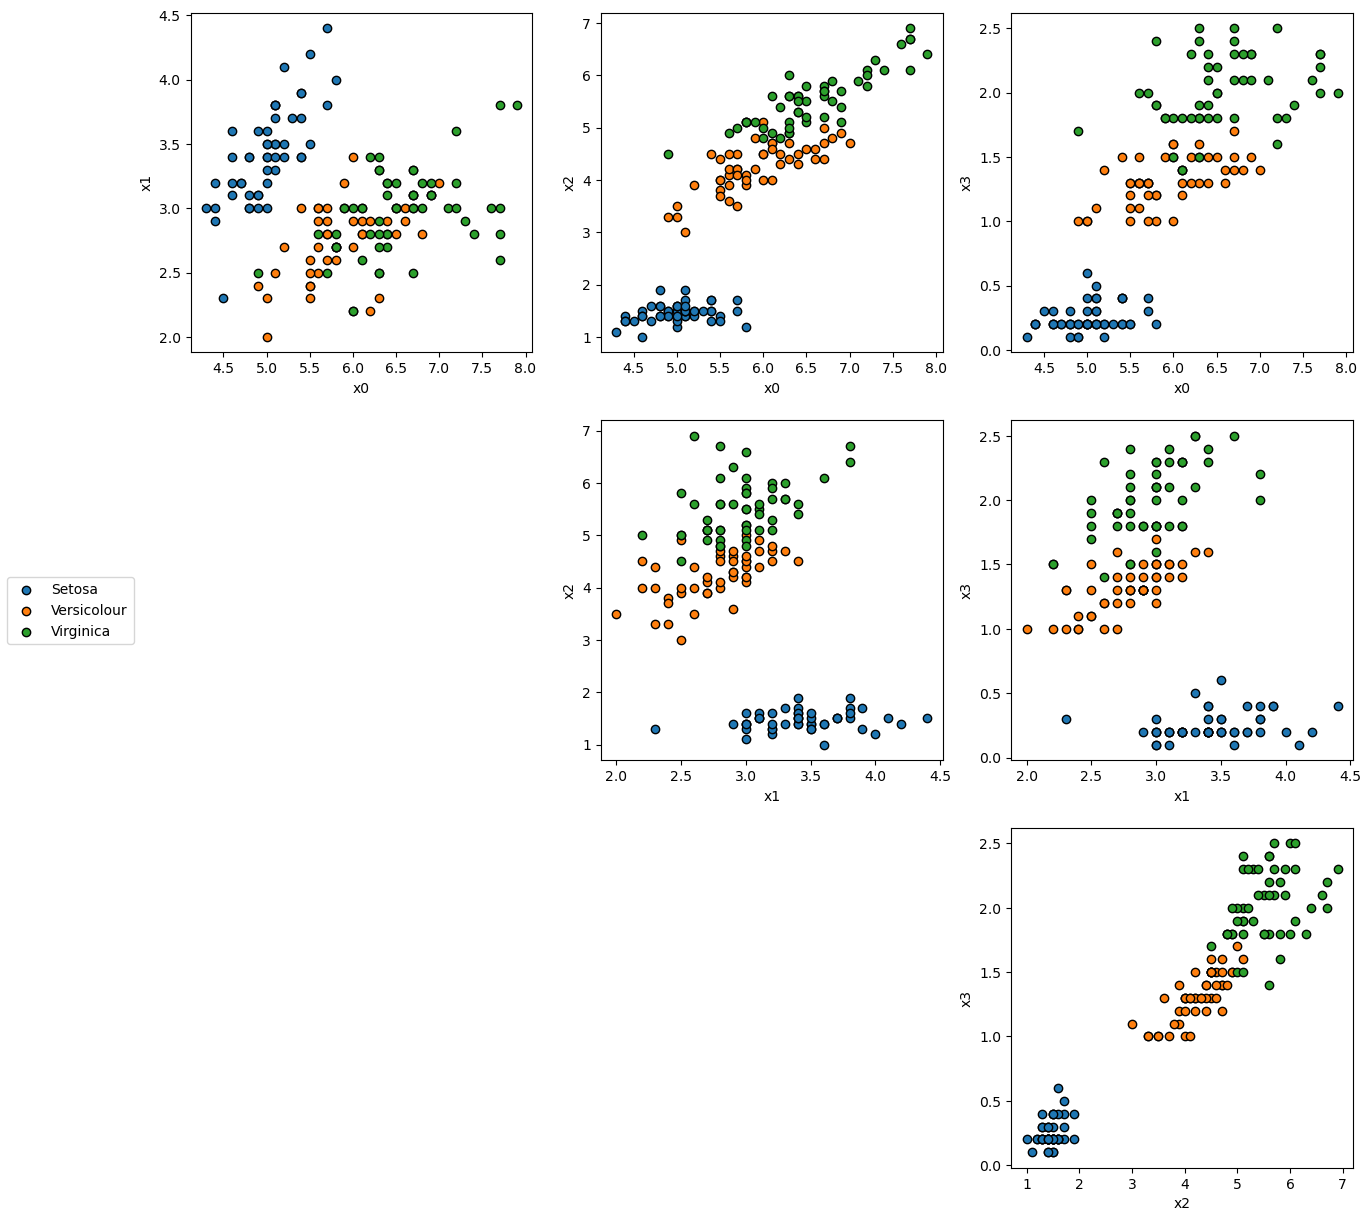

In [5]:
fig = plt.figure(figsize=(15,15))

n_features = X.shape[1]

# Utilizzeremo i subplot
for i in range(n_features):
    for j in range(i+1, n_features):
        sub_plot = plt.subplot(3,3,3*i+j)
        sub_plot.set_xlabel(f'x{i}')
        sub_plot.set_ylabel(f'x{j}')
        sub_plot.scatter(X[y==0,i],X[y==0,j],edgecolor='k')
        sub_plot.scatter(X[y==1,i],X[y==1,j],edgecolor='k')
        sub_plot.scatter(X[y==2,i],X[y==2,j],edgecolor='k')

fig.legend(('Setosa','Versicolour','Virginica'),loc='center left')

plt.show()

In [6]:
# Calcoliamo la varianza totale del data set con la PCA a 4 componenti
pca = decomposition.PCA(n_components=4, svd_solver='full')
pca.fit(X)

total_variation = np.sum(pca.singular_values_**2)

print(f'Varianza totale: {total_variation:5.2f}')

Varianza totale: 681.37


In [7]:
# Calcoliamo la PCA a 3 e 2 componenti e vediamo quanta varianza rimane

pca2 = decomposition.PCA(n_components=2, svd_solver='full')
pca2.fit(X)

X_2 = pca2.transform(X)
tv_2 = np.sum(pca2.singular_values_**2)

pca3 = decomposition.PCA(n_components=3, svd_solver='full')
pca3.fit(X)

X_3 = pca3.transform(X)
tv_3 = np.sum(pca3.singular_values_**2)

print(f'Varianza totale a 2 componenti: {tv_2:5.2f}, pari al {tv_2*100/total_variation:5.2f}% del totale')
print(f'Varianza totale a 3 componenti: {tv_3:5.2f}, pari al {tv_3*100/total_variation:5.2f}% del totale')

Varianza totale a 2 componenti: 666.17, pari al 97.77% del totale
Varianza totale a 3 componenti: 677.82, pari al 99.48% del totale


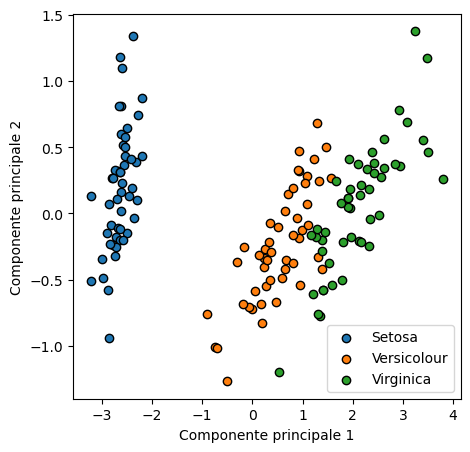

In [9]:
# Visualizziamo il data set trasformato a 2 componenti

fig =plt.figure(figsize=(5,5))

plt.xlabel('Componente principale 1')
plt.ylabel('Componente principale 2')

plt.scatter(X_2[y==0,0],X_2[y==0,1],label='Setosa',edgecolor='k')
plt.scatter(X_2[y==1,0],X_2[y==1,1],label='Versicolour',edgecolor='k')
plt.scatter(X_2[y==2,0],X_2[y==2,1],label='Virginica',edgecolor='k')

plt.legend()

plt.show()

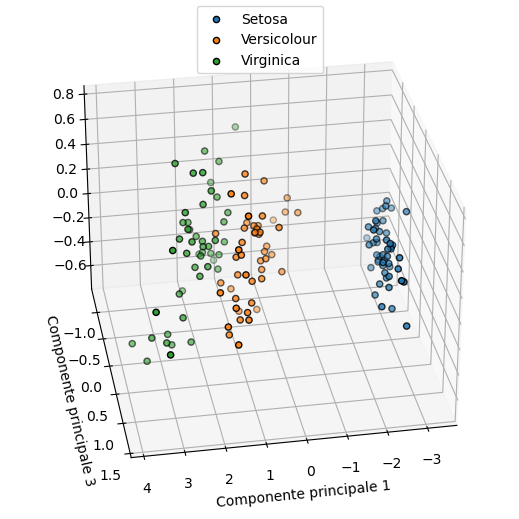

In [10]:
# Visualizziamo il data set trasformato a 3 componenti
from mpl_toolkits.mplot3d import axes3d

fig =plt.figure(figsize=(5,5))

ax = axes3d.Axes3D(fig)
fig.add_axes(ax)

ax.set_xlabel('Componente principale 1')
ax.set_ylabel('Componente principale 2')
ax.set_ylabel('Componente principale 3')

ax.scatter(X_3[y==0,0],X_3[y==0,1],X_3[y==0,2],label='Setosa',edgecolor='k')
ax.scatter(X_3[y==1,0],X_3[y==1,1],X_3[y==1,2],label='Versicolour',edgecolor='k')
ax.scatter(X_3[y==2,0],X_3[y==2,1],X_3[y==2,2],label='Virginica',edgecolor='k')

ax.view_init(elev=30,azim=80)

fig.legend(('Setosa','Versicolour','Virginica'),loc='upper center')

plt.show()

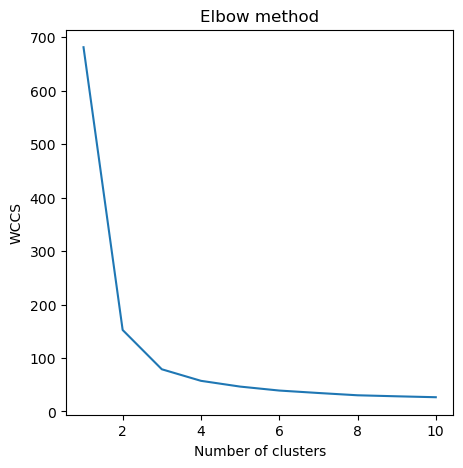

In [11]:
# Applichiamo l'elbow method per determinare il numero ottimale di cluster

wccs = []
kmeans = []

for i in range(1,11):
    kmeans.append(KMeans(n_clusters=i,
                         init='k-means++',
                         max_iter=300,
                         n_init=10,
                         random_state=42))
    kmeans[i-1].fit(X)
    wccs.append(kmeans[i-1].inertia_)

plt.figure(figsize=(5,5))

plt.plot(range(1,11),wccs)
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCCS')

plt.show()

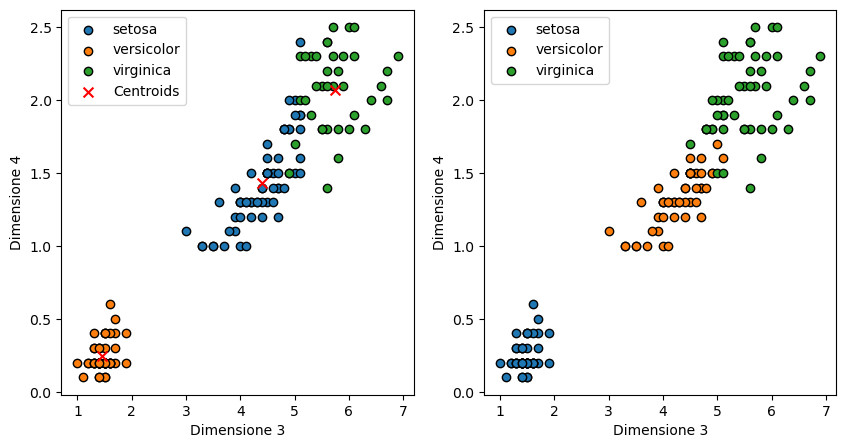

In [12]:
# Scegliamo il modello migliore a 3 cluster
best_model = kmeans[2]

y_best_model = best_model.fit_predict(X)


# Grafico comparativo clustering vs etichette di classe
labels = list(iris.target_names)
labels.append('Centroids')

fig = plt.figure(figsize=(10,5))

# Plot predizioni e centri dei cluster
subpl = fig.add_subplot(1,2,1)
subpl.set_xlabel('Dimensione 3')
subpl.set_ylabel('Dimensione 4')

subpl.scatter(X[y_best_model==0,2],X[y_best_model==0,3],edgecolor='k')
subpl.scatter(X[y_best_model==1,2],X[y_best_model==1,3],edgecolor='k')
subpl.scatter(X[y_best_model==2,2],X[y_best_model==2,3],edgecolor='k')

subpl.scatter(best_model.cluster_centers_[:,2],
              best_model.cluster_centers_[:,3],
              s=50,
              marker='x',
              color='r')

plt.legend(labels)

# Ploto etichette reali
subpl = fig.add_subplot(1,2,2)
subpl.set_xlabel('Dimensione 3')
subpl.set_ylabel('Dimensione 4')

subpl.scatter(X[y==0,2],X[y==0,3],edgecolor='k')
subpl.scatter(X[y==1,2],X[y==1,3],edgecolor='k')
subpl.scatter(X[y==2,2],X[y==2,3],edgecolor='k')

plt.legend(labels)

plt.show()


In [13]:
# Definiamo una esplicita funzione di remapping delle etichette di cluster verso
# le etichette di classe
def remap_cluster(ycluster, remap):
    '''remap_cluster: rimappa le etichette di cluster verso le etichette di classe

        Args:
            ycluster: (ndarray[int]) vettore delle etichette di cluster
            remap: (tuple[int,int]) lista degli swap di etichette
        
        Returns:
            y_remap: un vettore di interi che allinea le etichette con quelle di classe
    '''
    
    y_remap = np.ndarray(ycluster.shape, ycluster.dtype)
    
    y_remap.fill(-1)
    
    for da, a in remap:
        y_remap[ycluster == da] = a
    
    return y_remap

In [14]:
# Eseguiamo il remap
y_remap = remap_cluster(y_best_model,((0,1),(1,0),(2,2)))

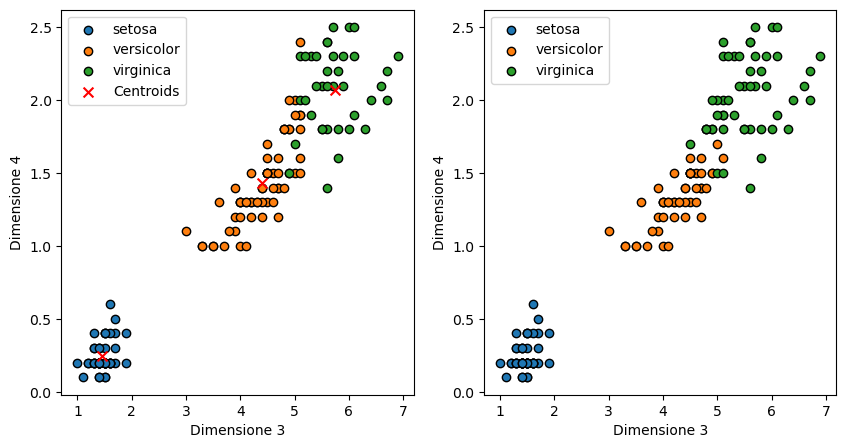

In [15]:
# Rifacciamo il plot
labels = list(iris.target_names)
labels.append('Centroids')

fig = plt.figure(figsize=(10,5))

# Plot predizioni e centri dei cluster
subpl = fig.add_subplot(1,2,1)
subpl.set_xlabel('Dimensione 3')
subpl.set_ylabel('Dimensione 4')

subpl.scatter(X[y_remap==0,2],X[y_remap==0,3],edgecolor='k')
subpl.scatter(X[y_remap==1,2],X[y_remap==1,3],edgecolor='k')
subpl.scatter(X[y_remap==2,2],X[y_remap==2,3],edgecolor='k')

subpl.scatter(best_model.cluster_centers_[:,2],
              best_model.cluster_centers_[:,3],
              s=50,
              marker='x',
              color='r')

plt.legend(labels)

# Ploto etichette reali
subpl = fig.add_subplot(1,2,2)
subpl.set_xlabel('Dimensione 3')
subpl.set_ylabel('Dimensione 4')

subpl.scatter(X[y==0,2],X[y==0,3],edgecolor='k')
subpl.scatter(X[y==1,2],X[y==1,3],edgecolor='k')
subpl.scatter(X[y==2,2],X[y==2,3],edgecolor='k')

plt.legend(labels)

plt.show()

[[50  0  0]
 [ 0 48  2]
 [ 0 14 36]]


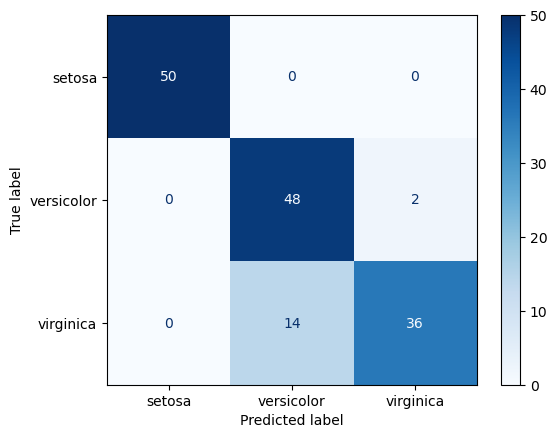

In [16]:
# Calcoliamo e mostriamo la matrice di confusione
cm = confusion_matrix(y, y_remap)

print(cm)

ConfusionMatrixDisplay.from_predictions(y,
                                        y_remap,
                                        display_labels=iris.target_names,
                                        cmap=plt.cm.Blues)

In [17]:
def cluster_metrics(cm):
    '''cluster_metrics: stampa i valori di Purity e Gini Index a partire da una matrice di confusione
    
        Args:
            cm: (ndarray) la matrice di confusione del clustering in oggetto
        
        Returns:
            metrics: (tuple[float, float]) la coppia di metriche
    
    '''

    M = np.array([np.sum(cm[:,i]) for i in range(cm.shape[1])])
    
    P = np.array([np.max(cm[:,i]) for i in range(cm.shape[1])])
    
    purity = np.sum(P)/np.sum(M)
    
    gini_values = [np.sum((cm[i,:]/M[i])**2) for i in range(cm.shape[0])]
    
    gini_j = 1 - np.array(gini_values)
    
    gini = np.dot(gini_j, M)/np.sum(M)
    
    return purity, gini

In [18]:
# Calcoliamo le metriche interne del nostro clustering

purity, gini = cluster_metrics(cm)

print(f'Purity: {purity:5.2f}\nGini index: {gini:5.2f}')

Purity:  0.89
Gini index:  0.16


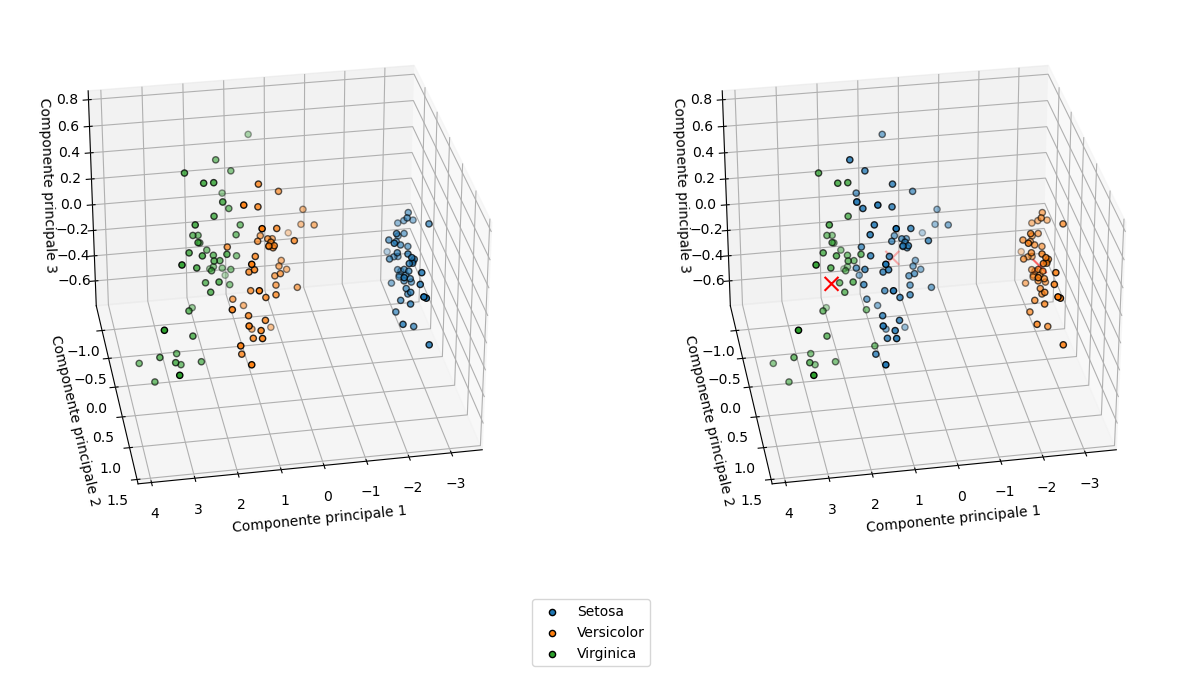

In [22]:
# K-means a 3 dimensioni
kmeans3 = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)

y_kmeans3 = kmeans3.fit_predict(X_3)

fig = plt.figure(figsize=(15,8))

# Plot data set reale
sub_plot = fig.add_subplot(121,projection='3d')

sub_plot.set_xlabel('Componente principale 1')
sub_plot.set_ylabel('Componente principale 2')
sub_plot.set_zlabel('Componente principale 3')

sub_plot.scatter(X_3[y==0,0],X_3[y==0,1],X_3[y==0,2],label='Setosa',edgecolor='k')
sub_plot.scatter(X_3[y==1,0],X_3[y==1,1],X_3[y==1,2],label='Versicolour',edgecolor='k')
sub_plot.scatter(X_3[y==2,0],X_3[y==2,1],X_3[y==2,2],label='Virginica',edgecolor='k')

sub_plot.view_init(elev=30,azim=80)

# Plot risultati del clustering
sub_plot = fig.add_subplot(122,projection='3d')

sub_plot.set_xlabel('Componente principale 1')
sub_plot.set_ylabel('Componente principale 2')
sub_plot.set_zlabel('Componente principale 3')

sub_plot.scatter(X_3[y_kmeans3==0,0],X_3[y_kmeans3==0,1],X_3[y_kmeans3==0,2],label='Setosa',edgecolor='k')
sub_plot.scatter(X_3[y_kmeans3==1,0],X_3[y_kmeans3==1,1],X_3[y_kmeans3==1,2],label='Versicolour',edgecolor='k')
sub_plot.scatter(X_3[y_kmeans3==2,0],X_3[y_kmeans3==2,1],X_3[y_kmeans3==2,2],label='Virginica',edgecolor='k')

sub_plot.scatter(kmeans3.cluster_centers_[:,0],
                 kmeans3.cluster_centers_[:,1],
                 kmeans3.cluster_centers_[:,2],
                 s=100,
                 marker='x',
                 color='r')

sub_plot.view_init(elev=30,azim=80)

fig.legend(('Setosa','Versicolor','Virginica'),loc='lower center')

plt.show()


Purity:  0.89
Gini index:  0.16


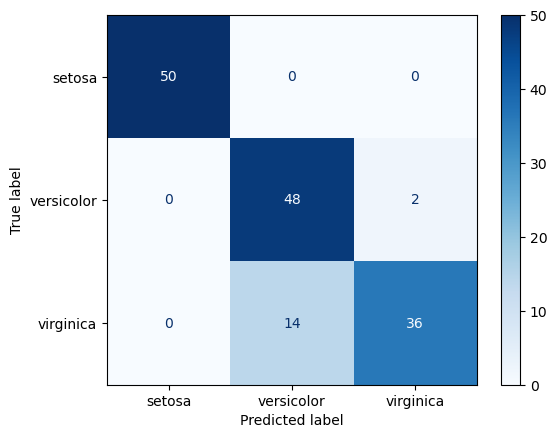

In [23]:
# Eseguo il remap
y_remap_kmeans3 = remap_cluster(y_kmeans3,((0,1),(1,0),(2,2)))

# Calcoliamo e mostriamo la matrice di confusione
cm3 = confusion_matrix(y, y_remap_kmeans3)

# Calcoliamo le misure di bontà interne
purity, gini = cluster_metrics(cm3)

print(f'Purity: {purity:5.2f}\nGini index: {gini:5.2f}')

ConfusionMatrixDisplay.from_predictions(y, 
                                        y_remap_kmeans3, 
                                        display_labels=iris.target_names,
                                        cmap=plt.cm.Blues)

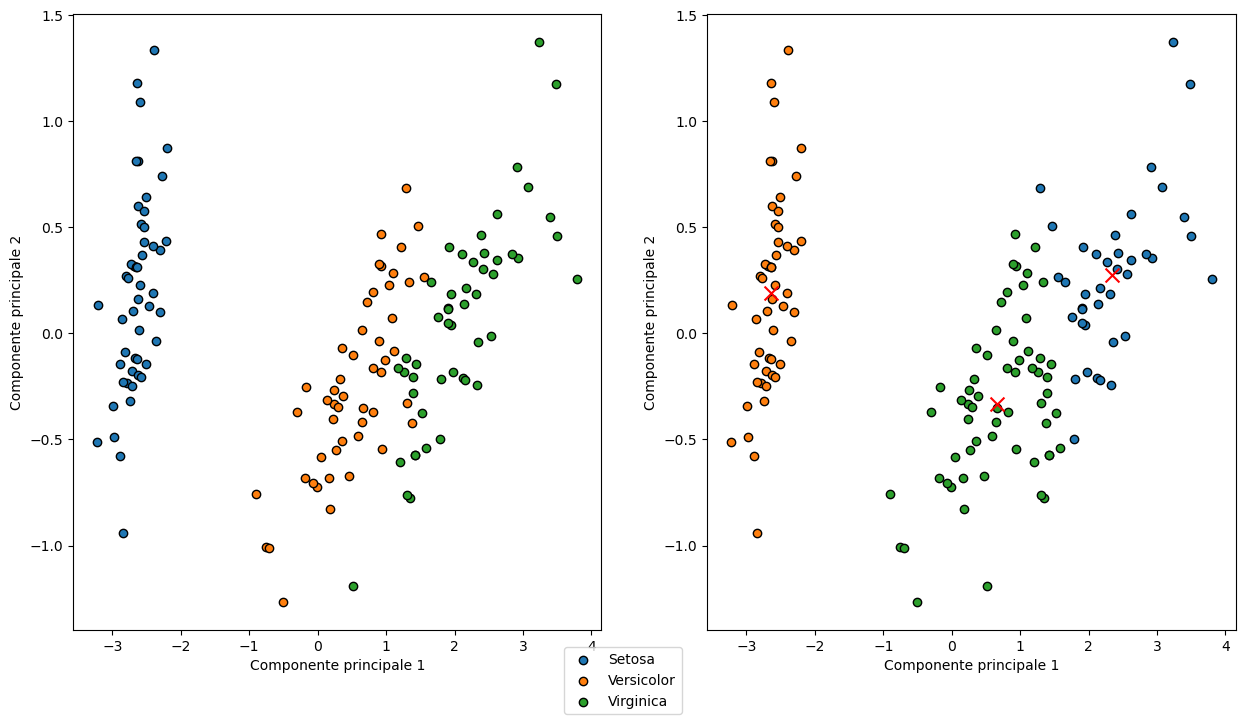

In [25]:
# Clustering a 2 dimensioni
kmeans2 = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)

y_kmeans2 = kmeans2.fit_predict(X_2)

fig = plt.figure(figsize=(15,8))

# Plot data set reale
sub_plot = fig.add_subplot(121)

sub_plot.set_xlabel('Componente principale 1')
sub_plot.set_ylabel('Componente principale 2')

sub_plot.scatter(X_2[y==0,0],X_2[y==0,1],label='Setosa',edgecolor='k')
sub_plot.scatter(X_2[y==1,0],X_2[y==1,1],label='Versicolour',edgecolor='k')
sub_plot.scatter(X_2[y==2,0],X_2[y==2,1],label='Virginica',edgecolor='k')

# Plot risultati del clustering
sub_plot = fig.add_subplot(122)

sub_plot.set_xlabel('Componente principale 1')
sub_plot.set_ylabel('Componente principale 2')

sub_plot.scatter(X_2[y_kmeans2==0,0],X_2[y_kmeans2==0,1],label='Setosa',edgecolor='k')
sub_plot.scatter(X_2[y_kmeans2==1,0],X_2[y_kmeans2==1,1],label='Versicolour',edgecolor='k')
sub_plot.scatter(X_2[y_kmeans2==2,0],X_2[y_kmeans2==2,1],label='Virginica',edgecolor='k')

sub_plot.scatter(kmeans2.cluster_centers_[:,0],
                 kmeans2.cluster_centers_[:,1],
                 s=100,
                 marker='x',
                 color='r')

fig.legend(('Setosa','Versicolor','Virginica'),loc='lower center')

plt.show()


Purity:  0.89
Gini index:  0.17


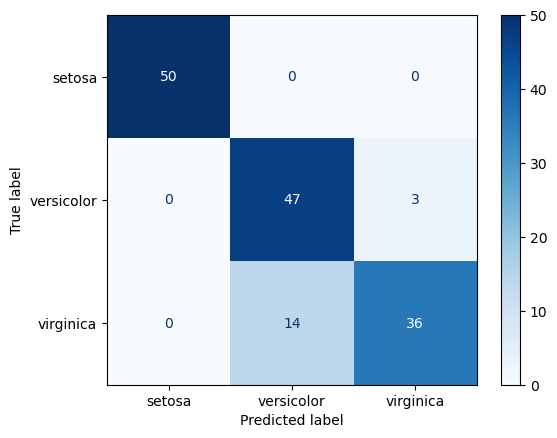

In [26]:
# Effettuiamo il remap
y_remap_kmeans2 = remap_cluster(y_kmeans2,((0,2),(1,0),(2,1)))

# Calcoliamo e mostriamo la matrice di confusione
cm2 = confusion_matrix(y, y_remap_kmeans2)

# Calcoliamo le misure di bontà interne
purity, gini = cluster_metrics(cm2)

print(f'Purity: {purity:5.2f}\nGini index: {gini:5.2f}')

ConfusionMatrixDisplay.from_predictions(y, 
                                        y_remap_kmeans2, 
                                        display_labels=iris.target_names,
                                        cmap=plt.cm.Blues)

